In [1]:
import pandas
import os
import numpy as np

In [2]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [3]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_caract = []

for year in years:
    df_caract_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"caract-{year}.csv"), encoding="utf-8", sep = ";")
    df_caract.append(df_caract_year)

df_caract = pandas.concat(df_caract)

In [4]:
# Drop ["adr","dep","com"] as we will work in our analysis with latitude and logitude and they contain this info already
df_caract.drop(columns=["adr","dep","com"],inplace=True)
df_caract.drop(columns=["an"],inplace=True) # Also we are not going to use year

In [5]:
df_caract.info()

<class 'pandas.DataFrame'>
Index: 327628 entries, 0 to 54401
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Num_Acc  327628 non-null  int64
 1   jour     327628 non-null  int64
 2   mois     327628 non-null  int64
 3   hrmn     327628 non-null  str  
 4   lum      327628 non-null  int64
 5   agg      327628 non-null  int64
 6   int      327628 non-null  int64
 7   atm      327628 non-null  int64
 8   col      327628 non-null  int64
 9   lat      327628 non-null  str  
 10  long     327628 non-null  str  
dtypes: int64(8), str(3)
memory usage: 30.0 MB


In [6]:
df_caract["lat"] = pandas.to_numeric(
    df_caract["lat"].str.replace(",", "."),
    errors="coerce"
)

df_caract["long"] = pandas.to_numeric(
    df_caract["long"].str.replace(",", "."),
    errors="coerce"
)

df_caract = df_caract.replace(-1, pandas.NA)

In [7]:
for col in df_caract.columns:
    prop = df_caract[col].isna().sum() / len(df_caract)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For jour proportion missing: 0.00%
For mois proportion missing: 0.00%
For hrmn proportion missing: 0.00%
For lum proportion missing: 0.00%
For agg proportion missing: 0.00%
For int proportion missing: 0.00%
For atm proportion missing: 0.01%
For col proportion missing: 0.49%
For lat proportion missing: 0.00%
For long proportion missing: 0.00%


In [8]:
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
hrmn          0
lum           9
agg           0
int          14
atm          26
col        1619
lat           0
long          1
dtype: int64

In [9]:
df_caract = df_caract.dropna()

In [10]:
column_names_to_int = ["jour", "mois", "lum", "agg", "int", "atm", "col"]

df_caract[column_names_to_int] = df_caract[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [11]:
df_caract[["lat", "long"]] = df_caract[["lat", "long"]].astype("float64")

In [12]:
df_caract["lat"].describe()

count    325968.000000
mean         44.340463
std          12.252725
min         -61.425660
25%          44.740342
50%          47.826994
75%          48.860363
max          63.568066
Name: lat, dtype: float64

In [13]:
df_caract["long"].describe()

count    325968.000000
mean          2.172269
std          19.093698
min        -178.158090
25%           1.281170
50%           2.391232
75%           4.795200
max         174.023438
Name: long, dtype: float64

In [14]:
invalid_lat = df_caract[
    (df_caract["lat"] < 41) | (df_caract["lat"] > 51)
]

len(invalid_lat) / len(df_caract)

0.05522014430864379

In [15]:
invalid_long = df_caract[
    (df_caract["long"] < -5) | (df_caract["long"] > 10)
]

len(invalid_long) / len(df_caract)

0.05463112943601826

In [16]:
df_caract = df_caract[
    (df_caract["lat"].between(41, 51)) &
    (df_caract["long"].between(-5, 10))
]

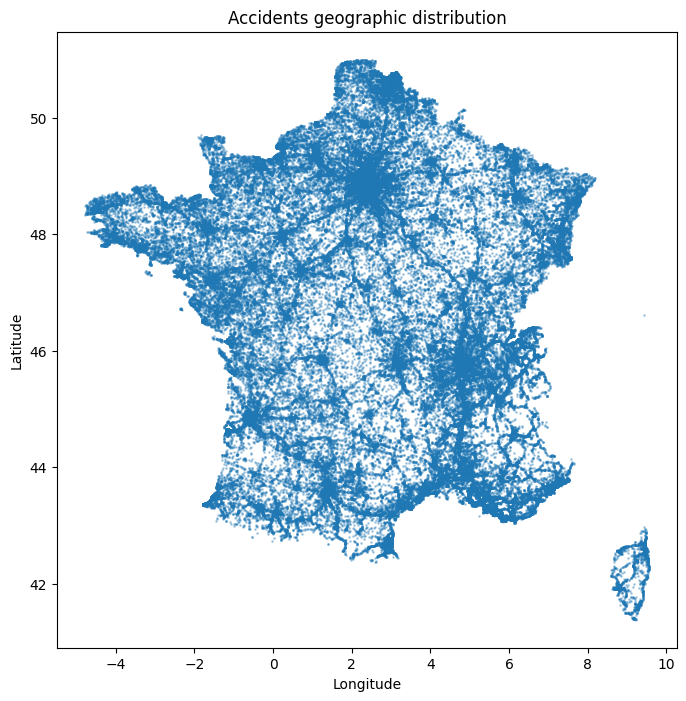

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(df_caract["long"], df_caract["lat"], s=1, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accidents geographic distribution")
plt.show()

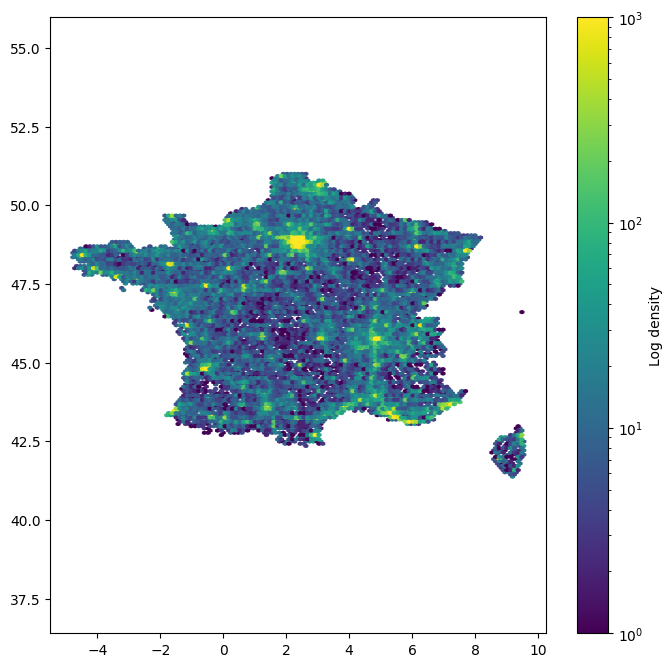

In [18]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract["long"],
    df_caract["lat"],
    gridsize=120,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=1000)
)

plt.colorbar(hb, label="Log density")
plt.axis("equal")
plt.show()

In [19]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_caract_with_target = df_caract.merge(
    df_usagers[['Num_Acc', 'grav_bin']],
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

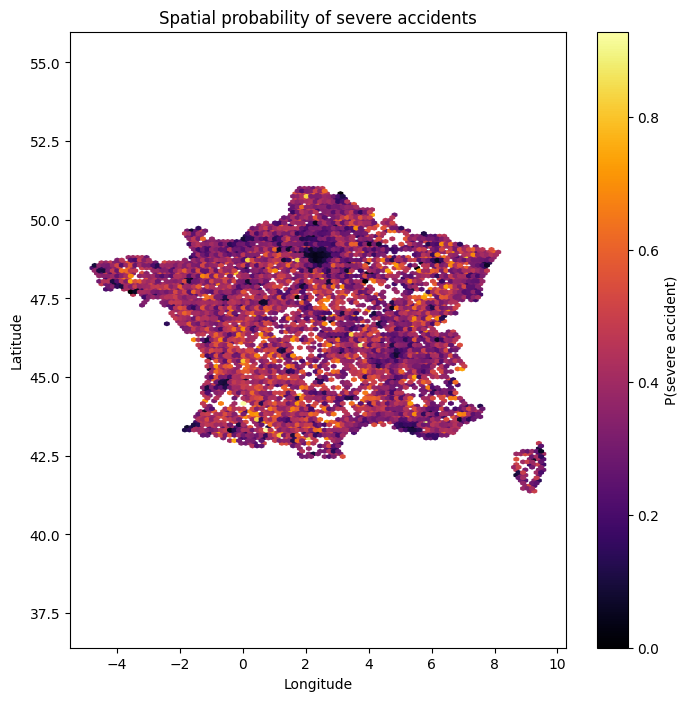

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract_with_target["long"],
    df_caract_with_target["lat"],
    C=df_caract_with_target["grav_bin"],
    reduce_C_function=np.mean, # probability of severe
    gridsize=100,
    cmap="inferno",
    mincnt=10 # ignore low-sample cells
)

plt.colorbar(hb, label="P(severe accident)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial probability of severe accidents")

plt.axis("equal")
plt.show()

Works OK with:
Decision Tree
Gradient Boosting ✅
These can split space like:
"if lat > 48.8 and long < 2.3 → high risk"
So they can learn regions.

Works poorly with:
Logistic Regression ❌
LDA / QDA ⚠️
They assume:
linear or Gaussian structure
which doesn’t match geography well

🔥 Option B — add nonlinear structure (VERY useful)
`from sklearn.preprocessing import PolynomialFeatures`
This lets Logistic Regression model regions:
lat², long², lat × long
👉 now it can approximate geographic zones

🔥 Option C — clustering (my top recommendation)
This is extremely powerful:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=50, random_state=42)
df_caract["geo_cluster"] = kmeans.fit_predict(df_caract[["lat", "long"]])
Then treat geo_cluster as categorical.

👉 This turns coordinates into:
“which geographic zone are you in?”
Much easier for models to use.

In [21]:
df_caract['mois'].describe()

count    307937.000000
mean          6.710142
std           3.357691
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          12.000000
Name: mois, dtype: float64

In [22]:
df_caract['jour'].describe()

count    307937.000000
mean         15.632025
std           8.731055
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: jour, dtype: float64

In [23]:
df_caract['day_of_year'] = (df_caract['mois'] - 1) * 30 + df_caract['jour']
df_caract['day_sin'] = np.sin(2 * np.pi * df_caract['day_of_year'] / 365)
df_caract['day_cos'] = np.cos(2 * np.pi * df_caract['day_of_year'] / 365)

df_caract = df_caract.drop(columns=["jour","mois", "day_of_year"])

In [24]:
df_caract["hrmn"] = df_caract["hrmn"].str.replace(":", "", regex=False)
df_caract["hrmn"] = df_caract["hrmn"].astype(int)

In [25]:
df_caract['hrmn'].describe()

count    307937.000000
mean       1374.531742
std         550.900940
min           0.000000
25%         950.000000
50%        1450.000000
75%        1810.000000
max        2359.000000
Name: hrmn, dtype: float64

In [26]:
df_caract['hour_sin'] = np.sin(2 * np.pi * df_caract['hrmn']/2400)
df_caract['hour_cos'] = np.cos(2 * np.pi * df_caract['hrmn']/2400)

df_caract = df_caract.drop(columns=["hrmn"])

In [27]:
df_caract.columns

Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'day_sin',
       'day_cos', 'hour_sin', 'hour_cos'],
      dtype='str')

In [28]:
categorical_features_caract = [
 'lum',
 'agg',
 'int',
 'atm',
 'col'
]

numerical_features_caract = ['lat', 'long', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']

features = categorical_features_caract + numerical_features_caract

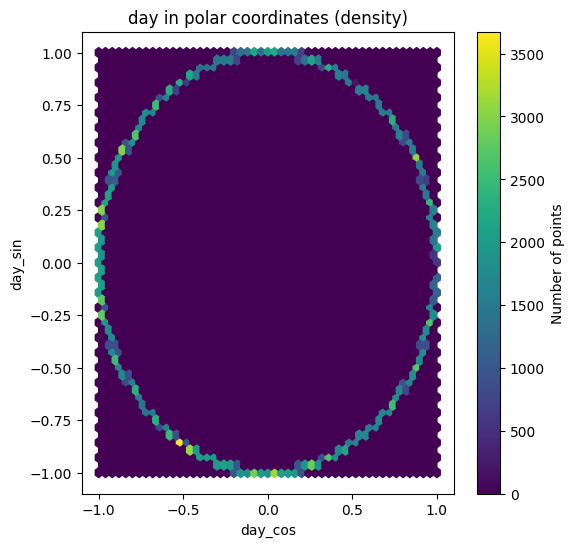

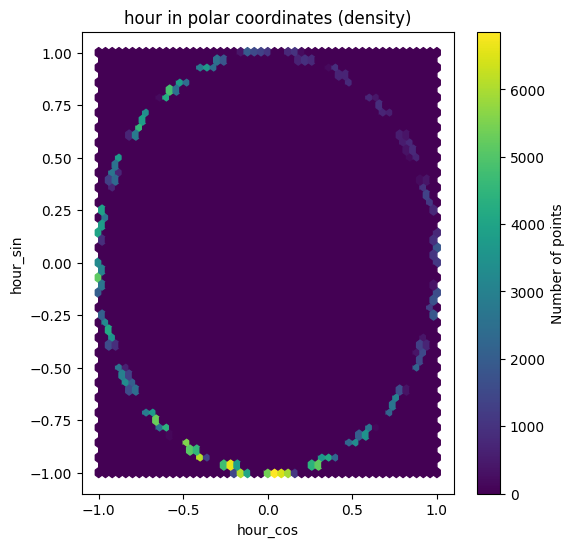

In [29]:
import matplotlib.pyplot as plt

pairs = [('day_cos', 'day_sin'), ('hour_cos', 'hour_sin')]

for x, y in pairs:
    plt.figure(figsize=(6,6))
    plt.hexbin(df_caract[x], df_caract[y], gridsize=50, cmap='viridis')
    plt.colorbar(label='Number of points')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x.split('_')[0]} in polar coordinates (density)")
    plt.show()

In [ ]:
df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_caract,
    on='Num_Acc',
    how='left'
)

In [31]:
df_caract_with_target.isna().sum()

Num_Acc      0
lum          0
agg          0
int          0
atm          0
col          0
lat          0
long         0
day_sin      0
day_cos      0
hour_sin     0
hour_cos     0
grav_bin    40
dtype: int64

In [32]:
df_caract_with_target = df_caract_with_target.dropna()

In [33]:
df_caract_analyse = df_caract_with_target.copy() 

In [34]:
df_caract_analyse['day_of_year'] = np.arctan2(df_caract_analyse['day_sin'], df_caract_analyse['day_cos'])
df_caract_analyse['day_of_year'] = (df_caract_analyse['day_of_year'] % (2*np.pi)) * 365 / (2*np.pi)

df_caract_analyse['hour'] = np.arctan2(df_caract_analyse['hour_sin'], df_caract_analyse['hour_cos'])
df_caract_analyse['hour'] = (df_caract_analyse['hour'] % (2*np.pi)) * 24 / (2*np.pi)

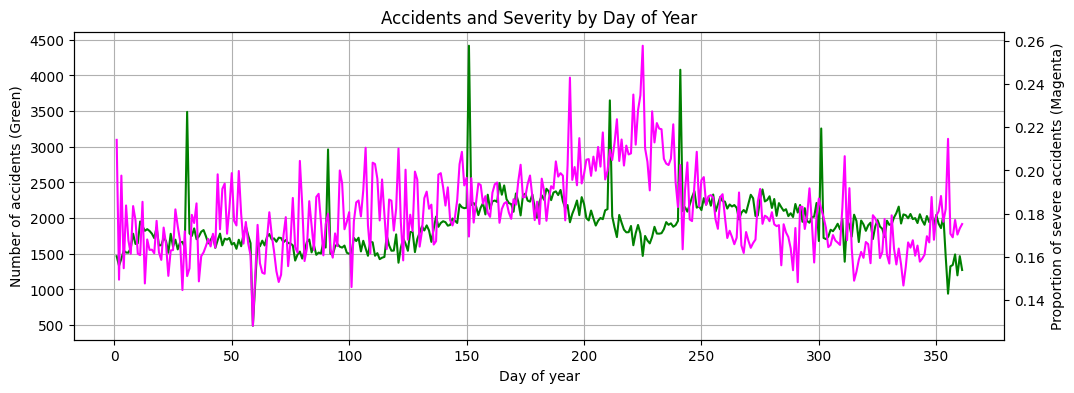

In [35]:
daily_counts = df_caract_analyse.groupby('day_of_year')['grav_bin'].count()
daily_severe = df_caract_analyse.groupby('day_of_year')['grav_bin'].mean()

fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(daily_counts.index, daily_counts.values, color = "GREEN")
ax1.set_xlabel("Day of year")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(daily_severe.index, daily_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents and Severity by Day of Year")
plt.show()

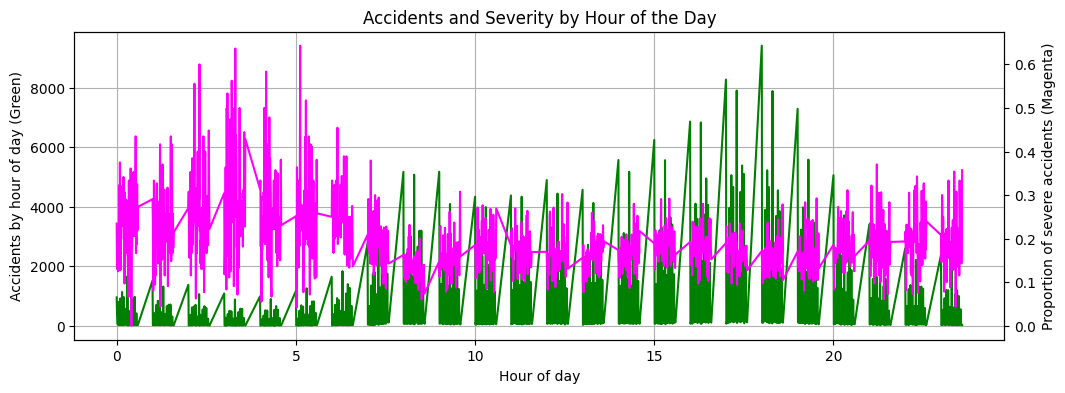

In [36]:
hourly_counts = df_caract_analyse.groupby('hour')['grav_bin'].count()
hourly_severe = df_caract_analyse.groupby('hour')['grav_bin'].mean()

fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(hourly_counts.index, hourly_counts.values, color = "GREEN")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Accidents by hour of day (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(hourly_severe.index, hourly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents and Severity by Hour of the Day")
plt.show()

In [37]:
mapping = {
    1: "Daylight",
    2: "Twilight or dawn",
    3: "Night without public lighting",
    4: "Night with public lighting not lit",
    5: "Night with public lighting lit"
}
df_caract_analyse["lum"] = df_caract_analyse["lum"].replace(mapping)

mapping = {
    1: "Outside built-up area",
    2: "Inside built-up area"
}
df_caract_analyse["agg"] = df_caract_analyse["agg"].replace(mapping)

mapping = {
    1: "No intersection",
    2: "X intersection",
    3: "T intersection",
    4: "Y intersection",
    5: "Intersection with more than 4 branches",
    6: "Roundabout",
    7: "Square",
    8: "Level crossing",
    9: "Other intersection"
}
df_caract_analyse["int"] = df_caract_analyse["int"].replace(mapping)

mapping = {
    1: "Normal",
    2: "Light rain",
    3: "Heavy rain",
    4: "Snow / hail",
    5: "Fog / smoke",
    6: "Strong wind / storm",
    7: "Dazzling weather (glare)",
    8: "Overcast",
    9: "Other"
}
df_caract_analyse["atm"] = df_caract_analyse["atm"].replace(mapping)

mapping = {
    1: "Two vehicles – head-on",
    2: "Two vehicles – rear-end",
    3: "Two vehicles – side collision",
    4: "Three or more vehicles – chain collision",
    5: "Three or more vehicles – multiple collisions",
    6: "Other collision",
    7: "No collision"
}
df_caract_analyse["col"] = df_caract_analyse["col"].replace(mapping)

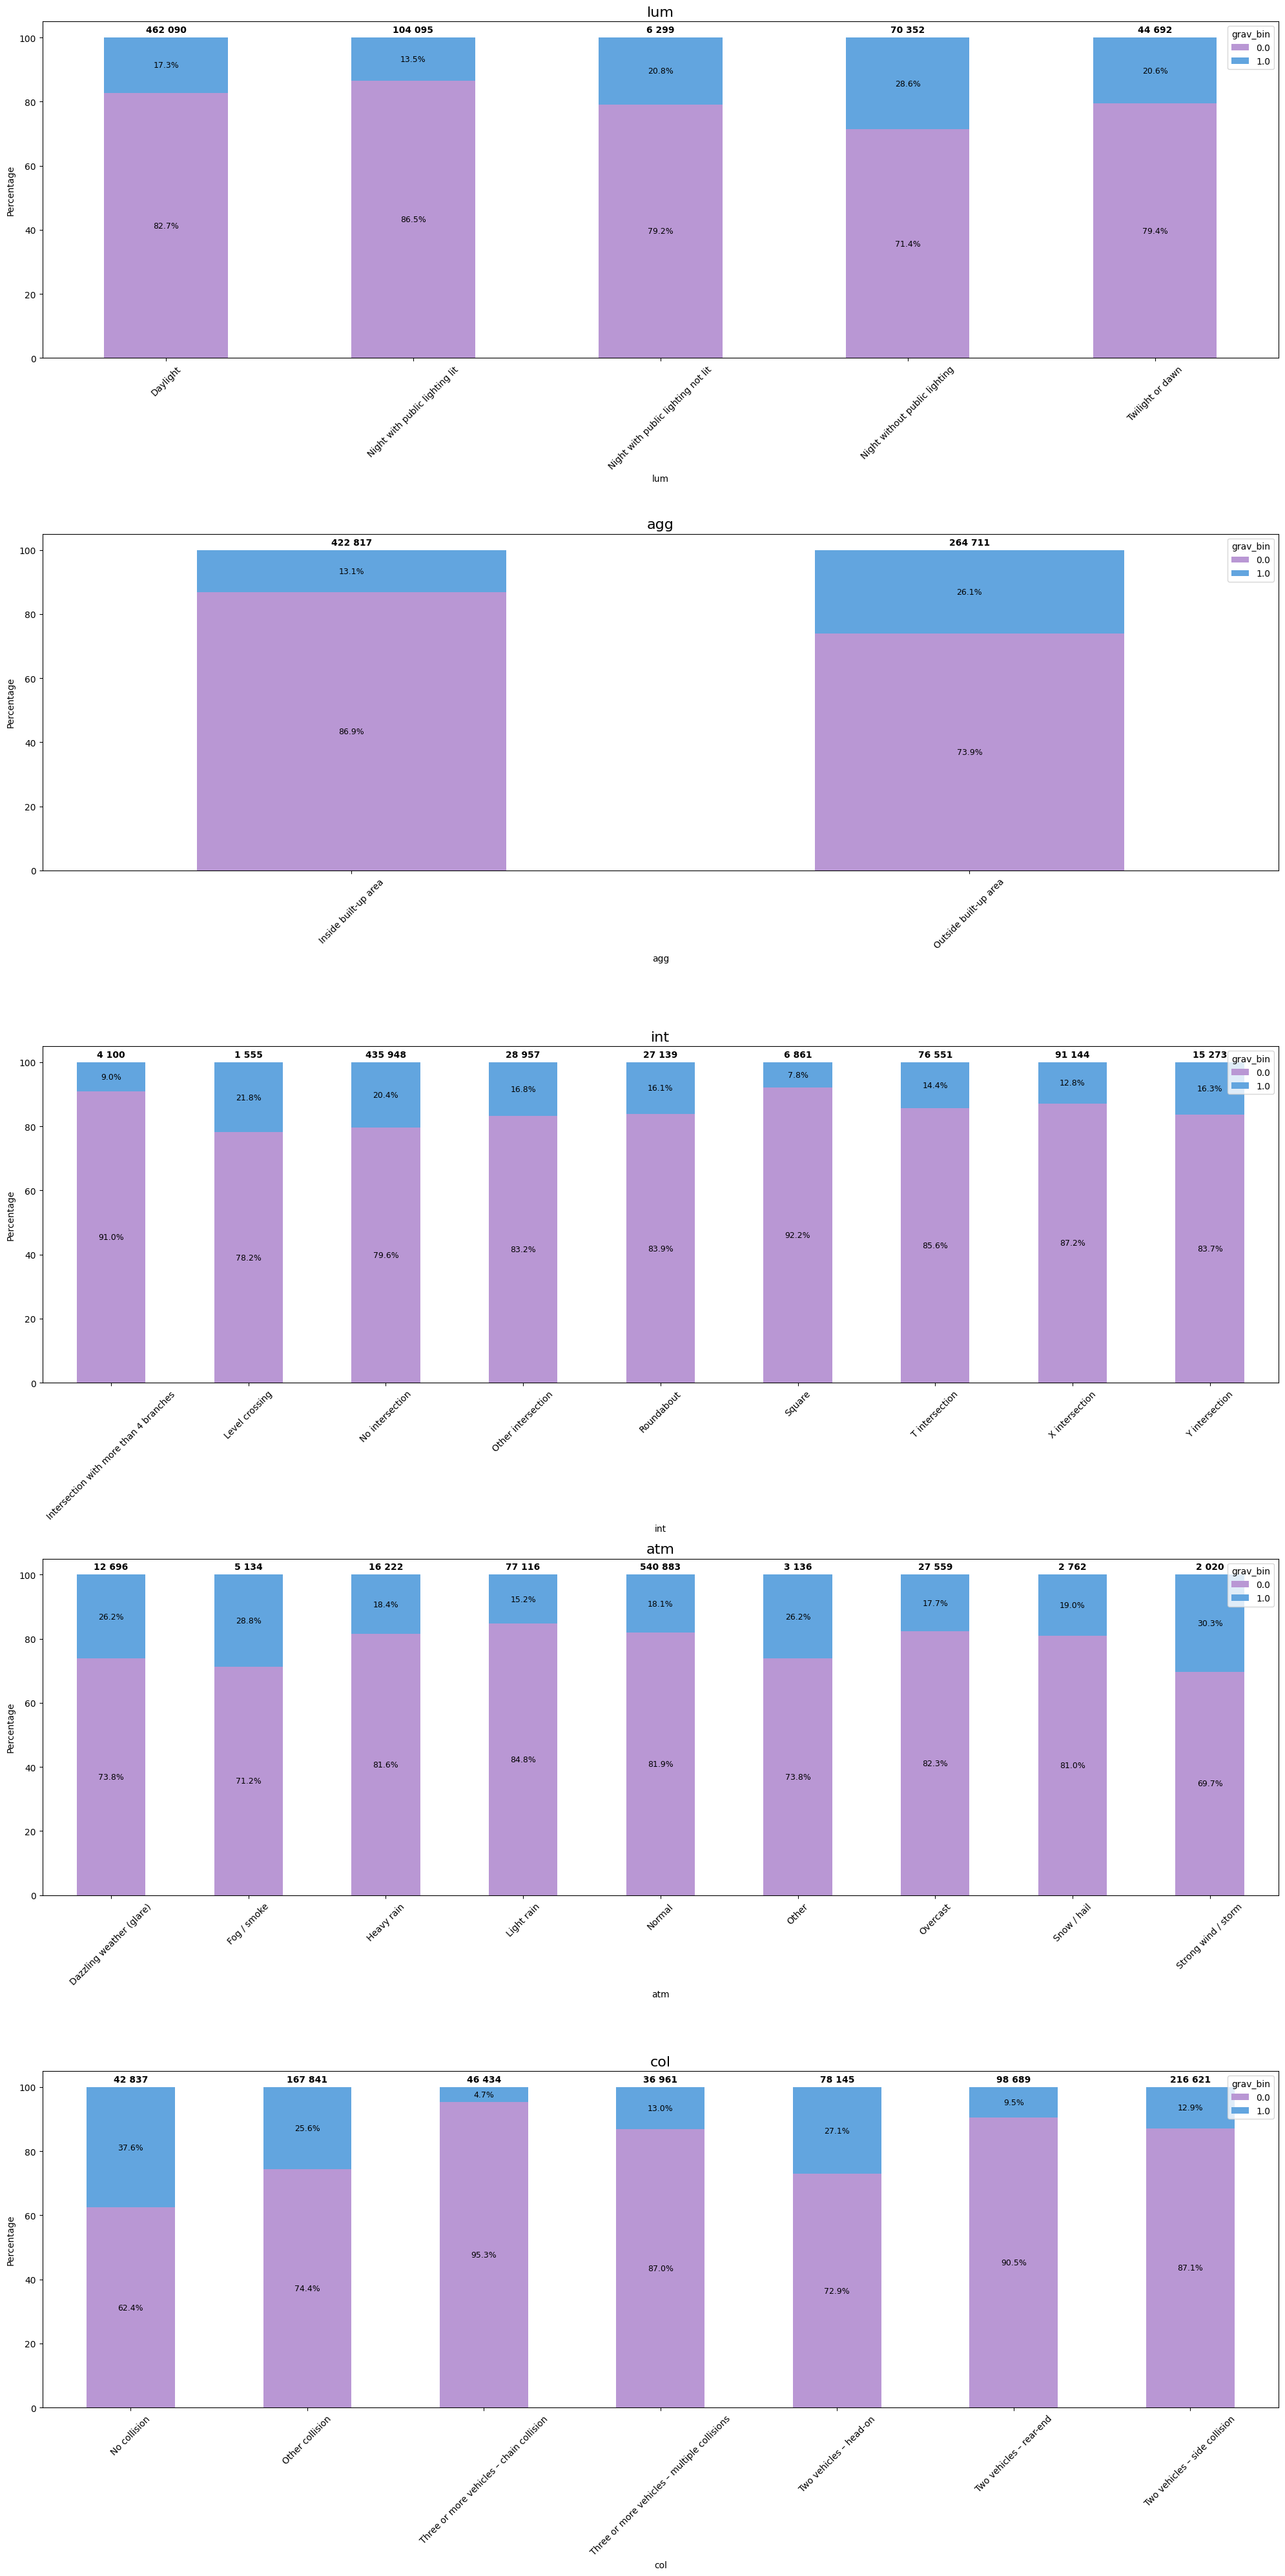

In [38]:
fig, ax = plt.subplots(len(categorical_features_caract), 1, figsize=(20, 6*len(categorical_features_caract) + 10))

df_caract_analyse = df_caract_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features_caract):
    ct = pandas.crosstab(
        df_caract_analyse[feature],
        df_caract_analyse[target],
        normalize="index"
    ) * 100

    counts = df_caract_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [ ]:
import pandas as pd

output_lines = []

for feature in categorical_features_caract:
    # Count per class
    counts = df_caract_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    
    # Proportions (in %)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    # Ensure column order (adapt if needed)
    # Assuming: 0 = not severe, 1 = severe
    for i, category in enumerate(counts.index):
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        # Replace commas for LaTeX formatting (French style spacing)
        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

# Print result
print("\n".join(output_lines))

\texttt{lum} & Daylight & 462 090 & 82.7 & 17.3 \\
 & Night with public lighting lit & 104 095 & 86.5 & 13.5 \\
 & Night with public lighting not lit & 6 299 & 79.2 & 20.8 \\
 & Night without public lighting & 70 352 & 71.4 & 28.6 \\
 & Twilight or dawn & 44 692 & 79.4 & 20.6 \\
\hline
\texttt{agg} & Inside built-up area & 422 817 & 86.9 & 13.1 \\
 & Outside built-up area & 264 711 & 73.9 & 26.1 \\
\hline
\texttt{int} & Intersection with more than 4 branches & 4 100 & 91.0 & 9.0 \\
 & Level crossing & 1 555 & 78.2 & 21.8 \\
 & No intersection & 435 948 & 79.6 & 20.4 \\
 & Other intersection & 28 957 & 83.2 & 16.8 \\
 & Roundabout & 27 139 & 83.9 & 16.1 \\
 & Square & 6 861 & 92.2 & 7.8 \\
 & T intersection & 76 551 & 85.6 & 14.4 \\
 & X intersection & 91 144 & 87.2 & 12.8 \\
 & Y intersection & 15 273 & 83.7 & 16.3 \\
\hline
\texttt{atm} & Dazzling weather (glare) & 12 696 & 73.8 & 26.2 \\
 & Fog / smoke & 5 134 & 71.2 & 28.8 \\
 & Heavy rain & 16 222 & 81.6 & 18.4 \\
 & Light rain & 7

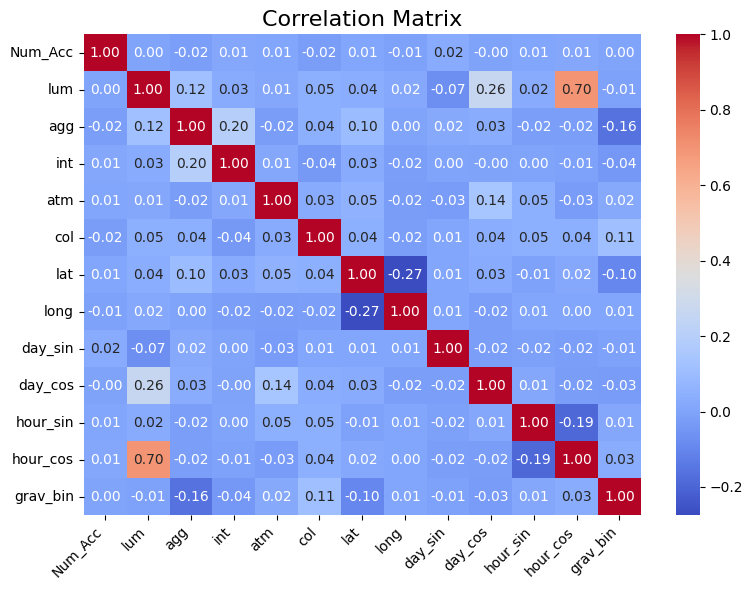

In [40]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_caract_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_caract),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_caract)
    ]
)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_caract_with_target[categorical_features_caract + numerical_features_caract]
y = df_caract_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

In [47]:
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.819302430439399

 Decision Tree
Accuracy: 0.7674356028100592

 Random Forest
Accuracy: 0.7695373292801768

 Gradient Boosting
Accuracy: 0.8227350079269268


AUC of Logistic Regression: 0.719
AUC of Decision Tree: 0.581
AUC of Random Forest: 0.709
AUC of Gradient Boosting: 0.760


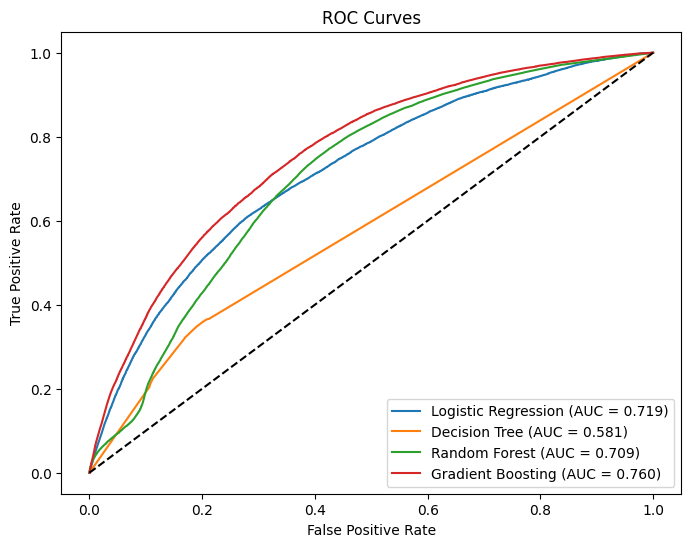

In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [49]:
# Finally we are going to save the dataset cleaned
df_caract.to_csv("df_caract_clean.csv", index=False)

In [50]:
df_caract = pandas.read_csv("df_caract_clean.csv")

In [51]:
print("All columns:", df_caract.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'day_sin',
       'day_cos', 'hour_sin', 'hour_cos'],
      dtype='str')
Features: ['lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
